In [1]:
import torch
from tqdm import tqdm
from torchinfo import summary
import matplotlib.pyplot as plt

In [2]:
import data_proc.data_preproc as data_preproc
import dino.dino_features as features

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cpu')

# load model

In [4]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
model.eval()

Using cache found in C:\Users\Jake Tallman/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [5]:
summary(model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
VisionTransformer                        [1, 384]                  301,824
├─PatchEmbed: 1-1                        [1, 64, 384]              --
│    └─Conv2d: 2-1                       [1, 384, 8, 8]            74,112
├─Dropout: 1-2                           [1, 65, 384]              --
├─ModuleList: 1-3                        --                        --
│    └─Block: 2-2                        [1, 65, 384]              --
│    │    └─LayerNorm: 3-1               [1, 65, 384]              768
│    │    └─Attention: 3-2               [1, 65, 384]              591,360
│    │    └─Identity: 3-3                [1, 65, 384]              --
│    │    └─LayerNorm: 3-4               [1, 65, 384]              768
│    │    └─Mlp: 3-5                     [1, 65, 384]              1,181,568
│    │    └─Identity: 3-6                [1, 65, 384]              --
│    └─Block: 2-3                        [1, 65, 384]         

In [6]:
model.to("cuda")

AssertionError: Torch not compiled with CUDA enabled

# Tiny Image Net

In [3]:
loader, loader_val = data_preproc.tiny_image_net_dataloaders()

cpu


torch.Size([64, 3, 224, 224])


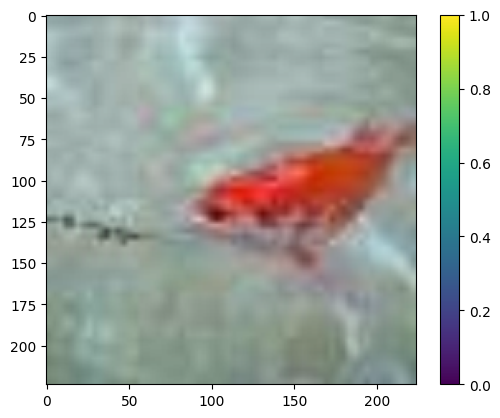

In [4]:
for batch in loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

In [55]:
# import random
#
# def frozen_features(model, loader, subsample_percent, device):
#     all_feats = []
#     all_labels = []
#     print()
#     with torch.no_grad():
#         for batch in tqdm(loader, total=len(loader)):
#             random_integer = random.randint(1, 100)
#
#             if random_integer <= subsample_percent:
#
#                 images = batch["image"]
#                 labels = batch["label"]
#
#                 images = images.to(device, non_blocking=True).float()
#
#                 feats = model(images)                # (B, D) CLS embedding
#                 all_feats.append(feats.cpu())
#                 all_labels.append(labels.cpu())
#
#     X = torch.cat(all_feats, dim=0)
#     y = torch.cat(all_labels, dim=0)
#
#     print(X.shape, y.shape)
#
#     return X, y

X, y = features.frozen_features(model, loader, device, subsample_percent=None, data_type="tiny_image_net")

In [59]:
subsample_percent = 10
model.eval().to(device)

X, y = features.frozen_features(model, loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val, y_val = features.frozen_features(model, loader_val, device, subsample_percent=None, data_type="tiny_image_net")


100%|██████████| 1563/1563 [09:16<00:00,  2.81it/s]


torch.Size([10048, 384]) torch.Size([10048])



100%|██████████| 157/157 [01:06<00:00,  2.37it/s]

torch.Size([1216, 384]) torch.Size([1216])


In [60]:
X.shape, y.shape #These are our class tokens and labels

(torch.Size([10048, 384]), torch.Size([10048]))

In [61]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X, y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [62]:
print (y)

tensor([  0,   0,   0,  ..., 199, 199, 199])


In [63]:
print(neigh.predict([X[1200]]))
print(y[1200])

[25]
tensor(25)


In [64]:
neigh.score(X_val, y_val)

0.4868421052631579